In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import DREAMS_utils
import pyEXP
import yaml
import k3d
from gala.units import SimulationUnitSystem
import astropy.units as u
import pynbody


/tmp/ipykernel_2043452/1214213953.py:45: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0,10**density_params_df["rangevals"][1]])


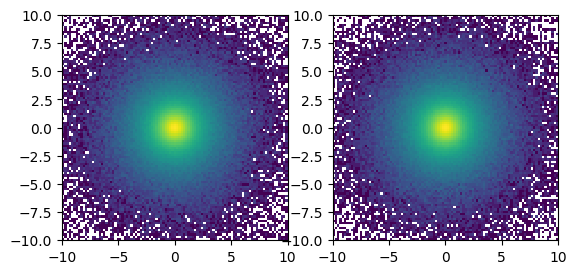

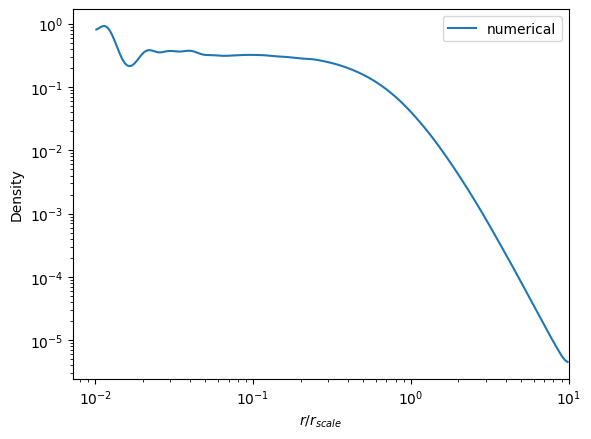

In [69]:
output_dir = "/mnt/home/asante/ceph/PlummerNbody/N6/"

outputs = os.listdir(output_dir)
outputs = [o for o in outputs if ".npz" in o]
# Order files by snapshot
t_outputs = sorted([float(out.replace("Plummer_outs_t","").replace(".npz","")) for out in outputs])
outputs = [f"Plummer_outs_t{int(t):03}.npz" for t in t_outputs]

lims = 10

# Load position, velocity, and masses of particles at last snapshot
data_final = np.load(f"{output_dir}{outputs[-1]}", allow_pickle=True)

# Create pynbody object and center particle distribution
sim = pynbody.new(dark=1000000)
sim["pos"] = data_final["x"]
sim["mass"] = data_final["m"]

pynbody.analysis.center(sim, with_velocity=False)

# Visualize cluster final configuration
fig,ax = plt.subplots(1,2)
_ = ax[0].hist2d(sim["pos"][:,0], sim["pos"][:,1], norm="log", bins=np.linspace(-lims,lims,100))
_ = ax[1].hist2d(sim["pos"][:,0], sim["pos"][:,2], norm="log", bins=np.linspace(-lims,lims,100))
ax[0].set_aspect(1)
ax[1].set_aspect(1)

logr = np.log10(np.sqrt(np.sum(sim["pos"]**2, axis=1)))
masses = sim["mass"]

# 1 - Calculate base density
density_params_df = {"bins": 200,
                     "rangevals": [-2,np.log10(lims)]}

rbins, dvals = DREAMS_utils.return_density(logr=logr, weights=masses, **density_params_df, smooth=True)


# Plot inferred density vs analytical density
fig,ax = plt.subplots()
ax.plot(rbins, dvals, label="numerical")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("$r/r_{scale}$")
ax.set_ylabel("Density")
ax.set_xlim([0,10**density_params_df["rangevals"][1]])
ax.legend()

In [70]:
# 2 - Set up basis
# Create an EXP-compatible spherical basis function table 
model_file = f"{output_dir}basis_empirical_PlummerTest.txt" 
cache_file = model_file.replace(".txt",".cache.run0")

# Check if model or table have already been computed
if os.path.exists(model_file):
    os.remove(model_file)
if os.path.exists(cache_file):
    os.remove(cache_file)

rbins, dvals, mass, potential = DREAMS_utils.makemodel_empirical(rvals=rbins,
                                                                 dvals=dvals,
                                                                 pfile=model_file) 
config = {"id" : "sphereSL",
            "parameters": {"numr": 1000,
                            "rmin": 0.01,
                            "rmax": 10,
                            "Lmax": 6,
                            "nmax": 20,
                            "rmapping": 0.1,
                            "modelname": model_file,
                            "cachename": model_file.replace(".txt",".cache.run0")
                            }
            }


# Save yaml file for constructing gala potential
yaml_file = f"{output_dir}basis_yaml_PlummerTest.yml"

with open(yaml_file, "w") as f:
    yaml.dump(config, f, default_flow_style=False)
    
    
# Construct basis
with open(yaml_file, "r") as f:
    yaml_config = f.read()

# Build the basis
basis = pyEXP.basis.Basis.factory(yaml_config) 


! Scaling:  R= 9.827935816415723   M= 1.0
0.9999999999999999 0.9849335248334261 0.9849335248334261 0.9849335248334261


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0 (File accessibility) Unable to open file>


---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.010901


In [71]:
# 3 - Calculate coefficients
coefs_container = None

for (t, output_file) in zip(t_outputs, outputs):
    
    data_file = np.load(f"{output_dir}{output_file}")
    
    # Center
    sim = pynbody.new(dark=1000000)
    sim["pos"] = data_file["x"]
    sim["mass"] = data_file["m"]

    pynbody.analysis.center(sim, with_velocity=False)

    coefs = basis.createFromArray(sim["mass"],
                                  sim["pos"], 
                                  time=t)
    
    if coefs_container is None:
        coefs_container = pyEXP.coefs.Coefs.makecoefs(coefs)
        coefs_container.add(coefs)
    else:
        coefs_container.add(coefs)
        
# Save the coefficients
coefs_file = f"{output_dir}coefs_PlummerTest.h5"
if os.path.exists(coefs_file):
    os.remove(coefs_file)
    coefs_container.WriteH5Coefs(coefs_file) 
else:
    coefs_container.WriteH5Coefs(coefs_file)
    

(-5.0, 5.0)

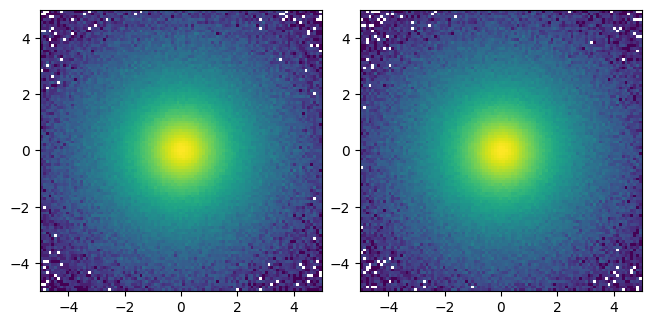

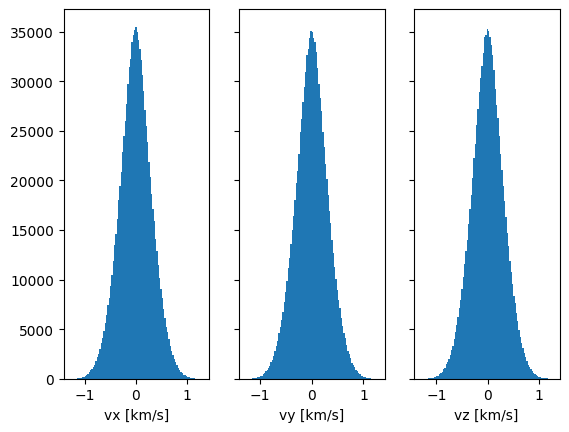

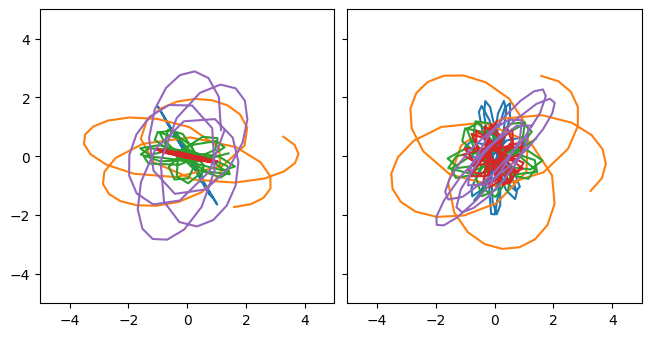

In [74]:
rng = np.random.default_rng(16)

x_lim = 5

xyz = data_file["x"]
fig,ax = plt.subplots(1,2, layout="constrained")
_ = ax[0].hist2d(xyz[:,0], xyz[:,1], norm="log", bins=np.linspace(-x_lim,x_lim,100))
_ = ax[1].hist2d(xyz[:,0], xyz[:,2], norm="log", bins=np.linspace(-x_lim,x_lim,100))
ax[0].set_aspect(1)
ax[1].set_aspect(1)

# Velocity distribution
v_xyz = data_file["v"]
fig1,ax = plt.subplots(1,3, sharey=True)
labels = ["vx [km/s]", "vy [km/s]", "vz [km/s]"]
for i in range(3):
    _ = ax[i].hist(v_xyz[:,i], bins=100)
    ax[i].set_xlabel(labels[i])
    
# Orbits
v_abs = np.sqrt(np.sum(v_xyz**2,axis=1))
idx_list = rng.integers(len(v_xyz), size=5)
fig2,axs = plt.subplots(1,2, layout="constrained", sharex=True, sharey=True)

pos = dict(zip(idx_list, [[] for i in range(len(idx_list))]))
vel = dict(zip(idx_list, [[] for i in range(len(idx_list))]))

for output_file in outputs:
    
    data_file = np.load(f"{output_dir}{output_file}")
    for idx in idx_list:
        x_idx = data_file["x"][idx]
        v_idx = data_file["v"][idx]
        pos[idx].append(x_idx)
        vel[idx].append(v_idx)

for idx in idx_list:
    p_xyz = np.vstack(pos[idx])
    axs[0].plot(p_xyz[:,0],p_xyz[:,1])
    axs[1].plot(p_xyz[:,0],p_xyz[:,2])
    
axs[0].set_aspect(1)
axs[1].set_aspect(1)
axs[0].set_xlim([-x_lim,x_lim])
axs[0].set_ylim([-x_lim,x_lim])

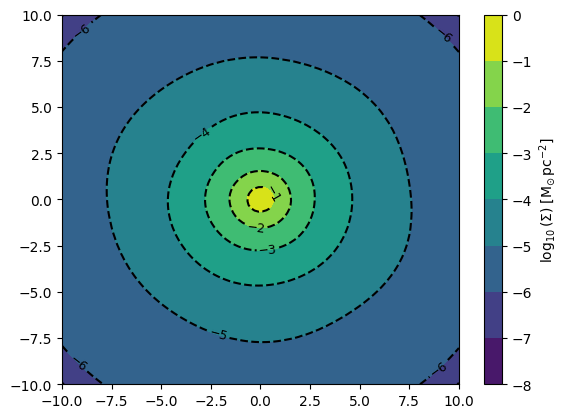

In [83]:
# Initialise surface field generator
times = coefs_container.Times()
field = "dens"
time = times[-1]

lim = 10.
grid = 100

generator = pyEXP.field.FieldGenerator(times, 
                                       [-lim, -lim, 0],
                                       [lim,lim,0],
                                       [grid,grid,0])

surfaces = generator.slices(basis, coefs_container)

surface = surfaces[time][field]

x = np.linspace(-lim,lim,grid)

y = np.linspace(-lim,lim,grid)

xv, yv = np.meshgrid(x, y)

fig, ax = plt.subplots()
cbar_label = field

if field in ["dens", "dens m=0", "dens m>0"]:

    # Convert to M_sun / kpc^2
    surface = np.log10(surface)
        
    cbar_label = "$\\log_{10}(\\Sigma) \\; [\\rm{M}_{\\odot} \\, \\rm{pc}^{-2}]$"

        
if field in ["potl", "potl m=0", "potl m>0"]:
    # Convert to (km/s)^2
    cbar_label = "$\\Phi \\; [\\rm{km}^2 \\, \\rm{s}^{-2}]$"


cont1 = ax.contour(xv, yv, surface, colors='k')
cont1.clabel(fontsize=9, inline=True)
cont2 = ax.contourf(xv, yv, surface)
cbar = fig.colorbar(cont2)
cbar.set_label(cbar_label)


In [84]:
# Visualize basis
field = "dens"
grid_lim = .50
n_points=100
time = coefs_container.Times()[-1]

times = coefs_container.Times()
pmin  = [-grid_lim, -grid_lim, -grid_lim]
pmax  = [grid_lim, grid_lim, grid_lim]
grid  = [n_points, n_points, n_points]

generator = pyEXP.field.FieldGenerator(times, pmin, pmax, grid)
volumes = generator.volumes(basis, coefs_container)

volume = volumes[time][field]

# Initialise plot
plot = k3d.plot()

value_range = [np.percentile(volume, 5), np.percentile(volume, 95)]
size = [-grid_lim, grid_lim, -grid_lim, grid_lim, -grid_lim, grid_lim]

volume = k3d.volume(volume.astype(np.float32), 
                    alpha_coef=250,
                    color_range=value_range,  
                    color_map=(np.array(k3d.colormaps.paraview_color_maps.Blues).reshape(-1,4) 
                    * np.array([1,1.0,1.0,1.0])).astype(np.float32), 
                    compression_level=7)

volume.transform.bounds = [-size[0], size[0], -size[1], size[1], -size[2], size[2]]

plot += volume

plot

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

# Build stream simulation

In [11]:
from gala.units import SimulationUnitSystem
import gala.potential as gp
import gala.dynamics as gd
import astropy.units as u
from gala.dynamics import mockstream as ms
import gala.integrate as gi
import math 

In [85]:
# Get snapshots time
exp_units = SimulationUnitSystem(mass=10**12*u.Msun, # Can decide here how big your system is
                                 length=10*u.kpc, # Specify what's the scale radius
                                 G=1)
    
t_min = coefs_container.Times()[0]*exp_units["time"].to(u.Gyr)
t_max = coefs_container.Times()[-1]*exp_units["time"].to(u.Gyr)
t_step = (coefs_container.Times()[1]-coefs_container.Times()[0])*exp_units["time"].to(u.Gyr)

print(f"Snapshots go from {t_min:.1f} to {t_max:.1f} Gyr with a timestep of {t_step:.2f} Gyr")

Snapshots go from 0.0 to 14.9 Gyr with a timestep of 0.30 Gyr


In [86]:
pot = gp.EXPPotential(units=exp_units,
                      config_file=yaml_file,
                      coef_file=coefs_file,
                      snapshot_time_unit=exp_units["time"])

pot_analytical = gp.PlummerPotential(m=1,
                                     b=1,
                                     units=exp_units)

---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.010901


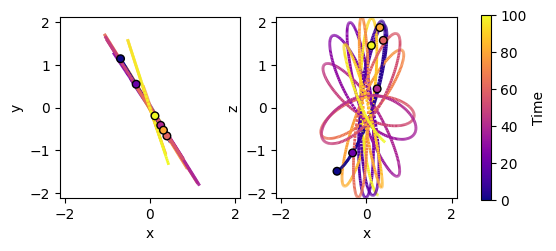

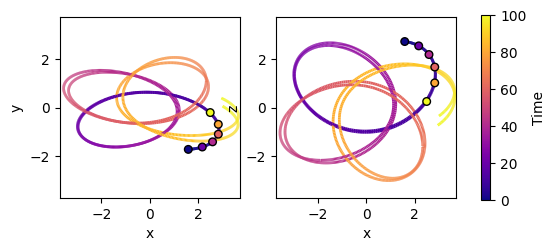

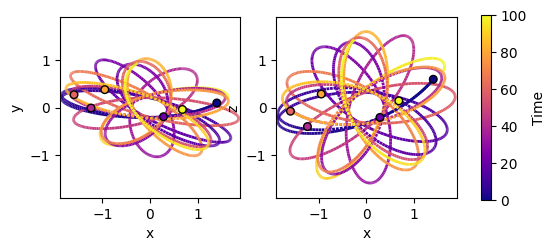

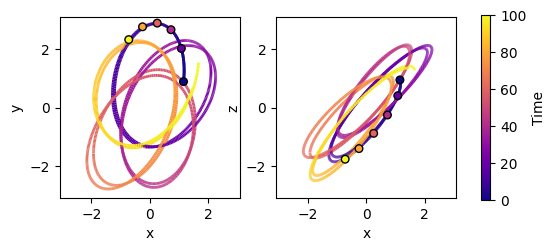

In [126]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

cmap = "plasma"

def plot_colored_line(ax, x, y, c, norm, cmap='viridis', linewidth=2, **kwargs):
    """
    Plots a line with a color gradient based on a third variable 'c'.
    
    Parameters
    ----------
    ax : Matplotlib Axes
        The axes to plot on.
    x, y : array-like
        The x and y coordinates of the data points.
    c : array-like
        The color values (e.g., time) that determine the color of each segment.
    cmap : str, optional
        The colormap to use (default is 'viridis').
    linewidth : int, optional
        The width of the line (default is 2).
    """
    # Create segments by pairing up consecutive points
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create a continuous norm to map the 'c' values to colors
    
    # Create the LineCollection
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth, **kwargs)
    
    # Set the color array
    # We use the 'c' values for the first point of each segment
    lc.set_array(c[:-1]) 
    
    # Add the collection to the axes and get the minimum/maximum limits
    ax.add_collection(lc)
    ax.autoscale_view() # Adjust the plot limits to encompass the new line
    
    return lc # Return the LineCollection object to use with a Colorbar


t2=100

for i,k in enumerate(pos.keys()):
    
    color = [rng.uniform(), rng.uniform(), rng.uniform()]
    orbit_xyz = np.vstack(pos[k])
    
    orbit_x0 = pos[k][0]
    orbit_v0 = vel[k][0]
    orbit_w0 = gd.PhaseSpacePosition(pos=orbit_x0*exp_units["length"],
                                     vel=orbit_v0*exp_units["velocity"])

    orbit_r = np.sqrt(np.sum(np.power(orbit_x0,2)))
    
    v_esc = math.sqrt(2*math.pi/orbit_r)

    orbit_period = 5*2*math.pi*orbit_r/v_esc
    
    norm = Normalize(0, t2)
    
    if orbit_period >= max(t_outputs):
        continue 
    
    elif orbit_period <20:
        continue
    

    orbit_analytical = pot_analytical.integrate_orbit(w0=orbit_w0, 
                                                      Integrator=gi.LeapfrogIntegrator,
                                                      t1=0, 
                                                      t2=t2*exp_units["time"], 
                                                      n_steps=1000)

    orbit_EXP = pot.integrate_orbit(w0=orbit_w0, 
                                    Integrator=gi.LeapfrogIntegrator, 
                                    t1=0, 
                                    t2=t2*exp_units["time"], 
                                    n_steps=1000)

    fig,axs = plt.subplots(1,2)
    p = plot_colored_line(axs[0], 
                          x=orbit_analytical.xyz[0], 
                          y=orbit_analytical.xyz[1],
                          c=orbit_analytical.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls="-")
    p = plot_colored_line(axs[0], 
                          x=orbit_EXP.xyz[0], 
                          y=orbit_EXP.xyz[1],
                          c=orbit_EXP.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls=":")
    p = plot_colored_line(axs[1], 
                          x=orbit_analytical.xyz[0], 
                          y=orbit_analytical.xyz[2],
                          c=orbit_analytical.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls="-")
    p = plot_colored_line(axs[1], 
                          x=orbit_EXP.xyz[0], 
                          y=orbit_EXP.xyz[2],
                          c=orbit_EXP.t.value,
                          cmap=cmap,
                          norm=norm,
                          ls=":")
    x = [orbit_xyz[:,0][i] for i in range(len(t_outputs)) if t_outputs[i]<=t2]
    y = [orbit_xyz[:,1][i] for i in range(len(t_outputs)) if t_outputs[i]<=t2]
    z = [orbit_xyz[:,2][i] for i in range(len(t_outputs)) if t_outputs[i]<=t2]
    axs[0].scatter(x, 
               y, 
               c=[t for t in t_outputs if t<=t2], 
               norm=norm,
               edgecolors="k",
               cmap=cmap,
               s=30, label='Simulation', zorder=100)
    
    axs[1].scatter(x, 
               z, 
               c=[t for t in t_outputs if t<=t2], 
               norm=norm,
               edgecolors="k",
               cmap=cmap,
               s=30, label='Simulation', zorder=100)
    
    lims = math.sqrt(max(np.sum(orbit_analytical.xyz.value**2,axis=0)))
    for ax in axs:
        ax.set_xlim([-lims, lims])
        ax.set_ylim([-lims,lims])
        ax.set_aspect(1)
        
    axs[0].set_xlabel("x")
    axs[1].set_xlabel("x")
    axs[0].set_ylabel("y")
    axs[1].set_ylabel("z")
    

    fig.colorbar(p, ax=axs, label='Time', shrink=0.5) 

Simulating GC disruption at x0=[-2.7219604  -2.22195197  0.38897943] kpc and v0=[ 109.99870963    2.74502895 -362.13810171] km / s
---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/PlummerNbody/N6/basis_empirical_PlummerTest.cache.run0>
---- Spherical::orthoTest: worst=0.010901
Simulation done in 19.36104416847229 seconds


Text(0.5, 0, 'x [kpc]')

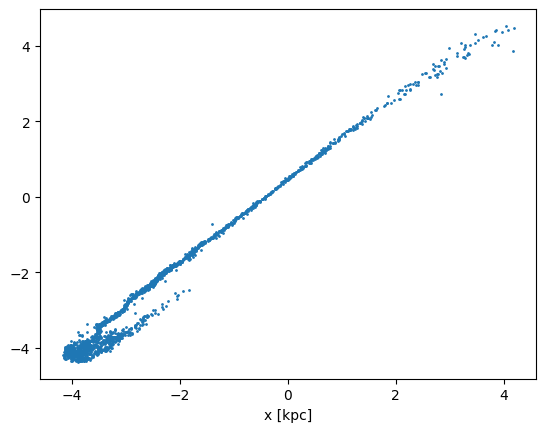

In [151]:
import time
# Stream sims parameters
t1 = 0
t2 = 200*exp_units["time"]
n_steps=1000


# Initialise stream ICs
gc_mass = 10**5*u.Msun
gc_pot = gp.PlummerPotential(m=gc_mass, 
                             b=4*u.pc, 
                             units=exp_units)

def sample_random_vector():
    v_magnitude = rng.normal(loc=0.0, scale=.3)
    random_components = rng.normal(loc=0.0, scale=1.0, size=3)
    norm = np.linalg.norm(random_components)
    unit_vector = random_components / norm
    return v_magnitude*unit_vector

x0 = sample_random_vector()*exp_units["length"]
v0 = sample_random_vector()*exp_units["velocity"]
print(f"Simulating GC disruption at x0={x0.to(u.kpc)} and v0={v0.to(u.km/u.s)}")
gc_w0 = gd.PhaseSpacePosition(pos=x0,
                              vel=v0)

# Initialise simulation submodels
gen_object = ms.MockStreamGenerator(df=ms.ChenStreamDF(lead=True, trail=True), # stream distribution function 
                                    hamiltonian=pot, # potential within which the stream is disrupted
                                    progenitor_potential=gc_pot 
                                    )
start = time.time()
stream_obj, _ = gen_object.run(prog_w0=gc_w0, # initial (or final) phase-space position of the progenitor system
                               prog_mass=gc_mass, # sets the scale mass of the particle release
                               release_every=1, # how many times particles are released at each time step
                               n_particles=1, # how many particles are released by the trail and the lead of the stream each time. Can be an array with same lenth as the timesteps,
                               t1=t1,
                               t2=t2,
                               n_steps = n_steps,
                               Integrator=gi.LeapfrogIntegrator
                               )  
print(f"Simulation done in {time.time()-start} seconds")

xyz = stream_obj.xyz.to(u.kpc)

fig,ax = plt.subplots()
ax.scatter(xyz[0], xyz[1], s=1)
ax.set_xlabel("x [kpc]")

In [149]:
v0

<Quantity [-0.31980396, -0.64755773,  0.12797756] 10.0 kpc / (3.8707679655184575 kpc(3/2) s kg(1/2) / (solMass(1/2) m(3/2)))>